In [33]:
import os

import pandas as pd
import numpy as np

import seaborn as sns

In [34]:
WRITE_FILES = False

In [35]:
working_dir = '/home/shiva/Datasets/V2_01_easy/V2_01_easy'

In [36]:
camera_type = 'cam1'

# CAM Changes
- CAM data was recorded at 20hz.
- Will now modify raw data and change it to 4 hz.

In [37]:
df = pd.read_csv(f'{working_dir}/mav0_euroc/{camera_type}/data.csv')

In [38]:
df['#timestamp [ns]'] = df['#timestamp [ns]'].astype('float64')

In [39]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   #timestamp [ns]  2280 non-null   float64
 1   filename         2280 non-null   object 
dtypes: float64(1), object(1)
memory usage: 35.8+ KB


In [40]:
# Check the deltas.
orig_deltas = np.unique(np.diff(df['#timestamp [ns]']), return_counts=True)

In [41]:
original_rate = 20
reduction_factor = 5
print("The frequency will be reduced to:", original_rate/reduction_factor)

The frequency will be reduced to: 4.0


In [42]:
# Reducing frequency
df = df.iloc[::reduction_factor]

In [43]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 2275
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   #timestamp [ns]  456 non-null    float64
 1   filename         456 non-null    object 
dtypes: float64(1), object(1)
memory usage: 7.3+ KB


In [44]:
df.head(5)

,#timestamp [ns],filename
0,1.413393e+18,1413393212255760384.png
5,1.413393e+18,1413393212505760512.png
10,1.413393e+18,1413393212755760384.png
15,1.413393e+18,1413393213005760512.png
20,1.413393e+18,1413393213255760384.png


In [45]:
# Check deltas after downsampling.
new_deltas = np.unique(np.diff(df['#timestamp [ns]']), return_counts=True)

In [46]:
#Since we have reduced the frequency, we should get a fractional value when we divide the original deltas by the new deltas
orig_deltas[0] / new_deltas[0]

array([0.19999959, 0.20000041])

In [47]:
df['#timestamp [ns]'] = df['#timestamp [ns]'].apply(lambda x: f"{x:.0f}")

In [48]:
df.head(10)

,#timestamp [ns],filename
0,1413393212255760384,1413393212255760384.png
5,1413393212505760512,1413393212505760512.png
10,1413393212755760384,1413393212755760384.png
15,1413393213005760512,1413393213005760512.png
20,1413393213255760384,1413393213255760384.png
25,1413393213505760512,1413393213505760512.png
30,1413393213755760384,1413393213755760384.png
35,1413393214005760512,1413393214005760512.png
40,1413393214255760384,1413393214255760384.png
45,1413393214505760512,1413393214505760512.png


In [49]:
# df.to_csv(f'{working_dir}/mav0_euroc/{camera_type}/data_downsampled_4hz.csv', index=False)

In [348]:
max_jitter = [1_000, 100_000, 200_000, 500_000, 800_000, 1_000_000, 2_000_000]
selection = 0

In [349]:
mu = max_jitter[selection] * 0.5
sigma = max_jitter[selection]/4

In [350]:
def generate_error(mu, sigma):
    error = -1
    while error <0 or error > max_jitter[selection]:
        error = np.random.normal(mu, sigma, 1)[0]
    return error

In [351]:
default_ts_arr = df['#timestamp [ns]'].values.astype(int)

In [352]:
np.unique(np.diff(default_ts_arr))

array([49999872, 50000128])

In [353]:
steps = np.diff(default_ts_arr)
adjusted_steps = []
for step in steps:
    adjusted_steps.append(step + generate_error(mu, sigma))

adjusted_steps = np.array(adjusted_steps)

In [354]:
adjusted_steps = np.insert(adjusted_steps, 0, default_ts_arr[0], axis=0)

In [355]:
modified_ts_arr = np.cumsum(adjusted_steps)

In [356]:
np.unique(np.diff(modified_ts_arr))

array([50000384., 50000640., 50000896., 50001152., 50001408., 50001920.,
       50002688., 50002944., 50003200., 50003456., 50003712., 50004736.,
       50004992., 50005248., 50005504., 50006272., 50006528., 50006784.,
       50007040., 50007296., 50007552., 50007808., 50008064., 50008320.,
       50008576., 50008832., 50009344., 50009600., 50009856., 50010112.,
       50010368., 50010624., 50010880., 50011136., 50011392., 50011648.,
       50011904., 50012160., 50012416., 50012672., 50012928., 50013184.,
       50013440., 50013696., 50013952., 50014208., 50014464., 50014720.,
       50014976., 50015232., 50015488., 50015744., 50016000., 50016256.,
       50016512., 50016768., 50017024., 50017280., 50017536., 50017792.,
       50018048., 50018304., 50018560., 50018816., 50019072., 50019328.,
       50019584., 50019840., 50020096., 50020352., 50020608., 50020864.,
       50021120., 50021376., 50021632., 50021888., 50022144., 50022400.,
       50022656., 50022912., 50023168., 50023424., 

In [357]:
df['#timestamp [ns]'] = modified_ts_arr

<Axes: xlabel='position', ylabel='delta'>

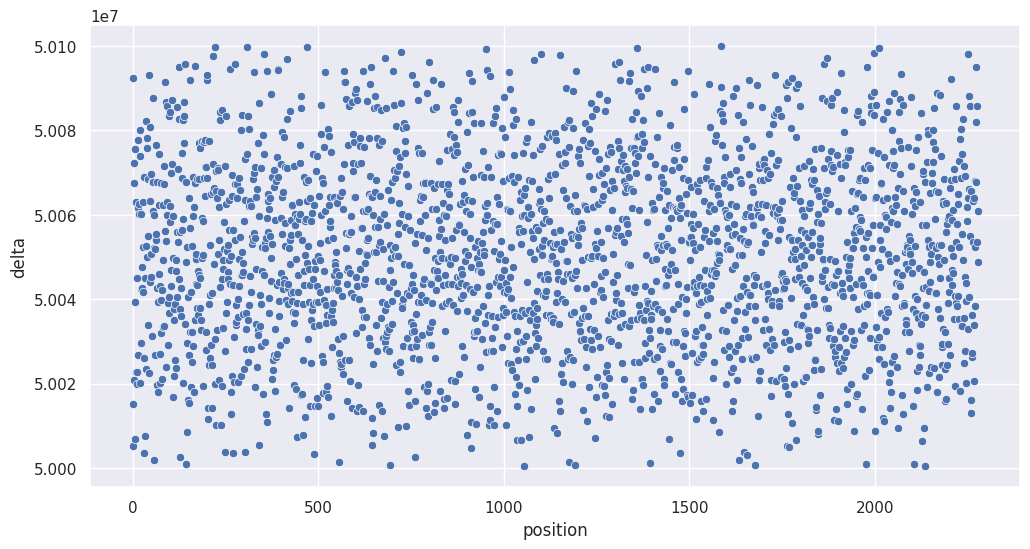

In [358]:
deltas = np.diff(modified_ts_arr)
delta_df = pd.DataFrame({'position': np.arange(0, len(deltas)) , 'delta':deltas})
sns.set_theme(rc={'figure.figsize':(12, 6)})
sns.scatterplot(data=delta_df, x='position', y='delta')

<Axes: xlabel='delta'>

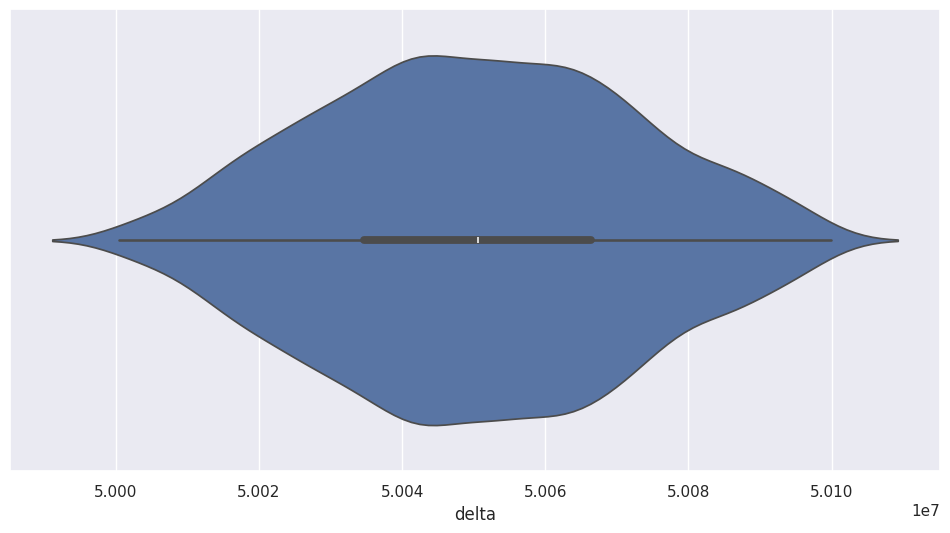

In [359]:
sns.violinplot(data=delta_df, x='delta')

In [360]:
df.head(5)

,#timestamp [ns],filename
0,1.413393e+18,1413393212255760384.png
1,1.413393e+18,1413393212305760512.png
2,1.413393e+18,1413393212355760384.png
3,1.413393e+18,1413393212405760512.png
4,1.413393e+18,1413393212455760384.png


In [361]:
df['#timestamp [ns]'] = df['#timestamp [ns]'].apply(lambda x: f"{x:.0f}")

In [362]:
df.head(5)

,#timestamp [ns],filename
0,1413393212255760384,1413393212255760384.png
1,1413393212305775616,1413393212305760512.png
2,1413393212355780864,1413393212355760384.png
3,1413393212405873408,1413393212405760512.png
4,1413393212455894272,1413393212455760384.png


In [363]:
df.tail(5)

,#timestamp [ns],filename
2275,1413393326120627200,1413393326005760512.png
2276,1413393326170680832,1413393326055760384.png
2277,1413393326220766720,1413393326105760512.png
2278,1413393326270815488,1413393326155760384.png
2279,1413393326320876288,1413393326205760512.png


In [365]:
filename = f'data_modified_{max_jitter[selection] / 1000000}ms_jitter.csv'

In [367]:
if WRITE_FILES:
    df.to_csv(f'{working_dir}/mav0_euroc/{camera_type}/{filename}', index=False)
    !cp {working_dir}/mav0_euroc/{camera_type}/{filename} /home/shiva/Datasets/V2_01_easy/V2_01_easy/mav0/{camera_type}/{filename}

### Rename files according to new timestamps.

In [369]:
if WRITE_FILES:
    mappings = {}

    for el in df.to_dict('records'):
        mappings[el['filename']] = el['#timestamp [ns]']
    
    for filename in os.listdir(f'{working_dir}/mav0/{camera_type}/data'):
        if filename in mappings.keys():
            os.rename(f'{working_dir}/mav0/{camera_type}/data/{filename}', f'{working_dir}/mav0/{camera_type}/data/{mappings[filename]}.png')